<h1>Resume Matching with BERT+Cosine and TF-IDF+Jaccard</h1>
<h2>Using Final.csv and Web Developer Job Description</h2>

This notebook implements resume matching using:
1. BERT embeddings with cosine similarity
2. TF-IDF with Jaccard similarity and all features
3. Text preprocessing to remove unnecessary columns (email, phone, LinkedIn, GitHub, etc.)
4. Web Developer job description for matching

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data (if not already present)
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')
    nltk.download('wordnet')

# For BERT embeddings
try:
    from sentence_transformers import SentenceTransformer
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'sentence-transformers'])
    from sentence_transformers import SentenceTransformer

print('All libraries imported successfully!')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


All libraries imported successfully!


In [2]:
# Load data
df = pd.read_csv('../data/raw/Final.csv')
with open('../data/job_descriptions/Web-Developer-job-description.txt', 'r', encoding='utf-8') as file:
    job_description = file.read()

print('Data loaded successfully.')

Data loaded successfully.


## Step 2: Text Preprocessing and Feature Calculation

Next, we perform the same text preprocessing and calculate the S-BERT and Jaccard similarity scores for the entire dataset. At this stage, we are just calculating features. No machine learning or target creation has occurred yet, so it's safe to do this on the full dataset.

In [3]:
# --- Text Preprocessing Functions (copied from previous notebook) ---
def clean_text(text):
    if pd.isna(text) or text == '': return ''
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    return ' '.join(text.split())

def preprocess_text(text):
    if pd.isna(text) or text == '': return ''
    text = clean_text(text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(tokens)

# --- Feature Calculation ---
unnecessary_columns = ['Contact Email', 'Phone Number', 'LinkedIn Profile', 'GitHub Profile', 'hyperlinks', 'Start Date (1st Experience)', 'End Date (1st Experience)','Location (1st Experience)', 'Graduation Year', 'Cumulative GPA']
df_cleaned = df.drop(columns=[col for col in unnecessary_columns if col in df.columns])

def combine_resume_text(row):
    text_fields = ['Job Title (1st Experience)', 'Company (1st Experience)', 'Job Responsibilities (1st Experience)', 'Project Title (1st Project)','Project Description (1st Project)', 'Project Tech Stack (1st Project)','Project Title (2nd Project)', 'Project Description (2nd Project)','Project Tech Stack (2nd Project)', 'Skills - Proficient', 'Skills - Experienced', 'Skills - Familiar', 'Education Degree','Education Institution', 'Achievements']
    combined_text = [str(row[field]) for field in text_fields if field in row and pd.notna(row[field]) and str(row[field]).strip()]
    return ' '.join(combined_text)

df_cleaned['combined_text'] = df_cleaned.apply(combine_resume_text, axis=1)
df_cleaned['processed_text'] = df_cleaned['combined_text'].apply(preprocess_text)
job_description_processed = preprocess_text(job_description)
df_cleaned = df_cleaned[df_cleaned['processed_text'].str.len() > 0].reset_index(drop=True)

# S-BERT Similarity
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
job_embedding = sbert_model.encode([job_description_processed])
resume_embeddings = sbert_model.encode(df_cleaned['processed_text'].tolist())
df_cleaned['sbert_similarity'] = cosine_similarity(job_embedding, resume_embeddings)[0]

# Jaccard Similarity
def jaccard_similarity_func(set1, set2):
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union != 0 else 0

tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english', lowercase=True, min_df=1, max_df=0.9)
all_texts = [job_description_processed] + df_cleaned['processed_text'].tolist()
tfidf_matrix = tfidf_vectorizer.fit_transform(all_texts)
feature_names = tfidf_vectorizer.get_feature_names_out()
job_tfidf = tfidf_matrix[0]
resume_tfidf = tfidf_matrix[1:]
job_term_set = set([feature_names[i] for i, score in enumerate(job_tfidf.toarray()[0]) if score > 0.01])
jaccard_similarities = [jaccard_similarity_func(job_term_set, set([feature_names[i] for i, score in enumerate(resume_tfidf[j].toarray()[0]) if score > 0.01])) for j in range(resume_tfidf.shape[0])]
df_cleaned['jaccard_similarity'] = jaccard_similarities

print('Preprocessing and feature calculation complete.')
print(f'Dataframe shape: {df_cleaned.shape}')
print(df_cleaned[['Name', 'sbert_similarity', 'jaccard_similarity']].head())

Preprocessing and feature calculation complete.
Dataframe shape: (144, 20)
                          Name  sbert_similarity  jaccard_similarity
0           Rakesh Gupta Kotha          0.605159            0.052885
1               Rakshit Sharma          0.467654            0.026738
2  Ravindhranadh Thakkellapati          0.512330            0.038462
3                Razina Khanam          0.240771            0.005587
4              Rishi Raj Singh          0.151710            0.000000


## Step 3: The CRITICAL Fix - Splitting Data BEFORE Target Creation

This is the most important step to prevent data leakage. We split our data into a training set and a test set **before** we do anything else related to model training. The test set will be held out and treated as truly "unseen" data until the final evaluation.

- **Why?** In the flawed notebook, the target variable was created using information from the *entire dataset*. This meant information from the test set was used to create the labels the model was trained on, allowing it to "cheat".
- **Our Approach:** By splitting first, we ensure that all subsequent steps (creating the target, scaling features, training the model) are performed **only on the training data**. The test data is kept completely separate.

In [4]:
X = df_cleaned.copy()
y_placeholder = df_cleaned['sbert_similarity'] # Just a placeholder for stratification, will be replaced

X_train, X_test = train_test_split(X, test_size=0.3, random_state=42)

print(f'Training set size: {X_train.shape[0]}')
print(f'Testing set size: {X_test.shape[0]}')

Training set size: 100
Testing set size: 44


## Step 4: Creating a Proxy Target Variable (The Right Way)

Since we don't have an external "ground truth" (e.g., labels from a human recruiter), we will create a *proxy* target variable. Our goal is to see if a model can learn to replicate our ranking system.

1. We calculate a `Combined_Score` from the similarity scores.
2. We find a threshold (e.g., the 70th percentile) based **only on the training data**.
3. We apply this **single threshold** to both the training and test sets to create our target variable `is_top_candidate`.

This correctly simulates a real-world scenario where you define a rule based on your existing data and then apply that rule to new, incoming data.

In [5]:
# Normalize scores and create Combined_Score for both sets
scaler = MinMaxScaler()
X_train['sbert_norm'] = scaler.fit_transform(X_train[['sbert_similarity']])
X_test['sbert_norm'] = scaler.transform(X_test[['sbert_similarity']])

X_train['jaccard_norm'] = scaler.fit_transform(X_train[['jaccard_similarity']])
X_test['jaccard_norm'] = scaler.transform(X_test[['jaccard_similarity']])

X_train['combined_score'] = (X_train['sbert_norm'] + X_train['jaccard_norm']) / 2
X_test['combined_score'] = (X_test['sbert_norm'] + X_test['jaccard_norm']) / 2

# Determine threshold ONLY from training data
threshold = np.percentile(X_train['combined_score'], 70)
print(f'Combined score threshold (from training data): {threshold:.4f}')

# Apply threshold to both sets
X_train['is_top_candidate'] = (X_train['combined_score'] >= threshold).astype(int)
X_test['is_top_candidate'] = (X_test['combined_score'] >= threshold).astype(int)

print('Training Set Class Distribution:')
print(X_train['is_top_candidate'].value_counts())

print('Test Set Class Distribution:')
print(X_test['is_top_candidate'].value_counts())

Combined score threshold (from training data): 0.5316
Training Set Class Distribution:
is_top_candidate
0    70
1    30
Name: count, dtype: int64
Test Set Class Distribution:
is_top_candidate
0    30
1    14
Name: count, dtype: int64


## Step 5: Feature Engineering

Now we create the additional keyword-based features. This can be done on both the training and test sets without causing leakage, as it doesn't use any information from the target variable.

In [6]:
web_dev_keywords = ['javascript', 'node', 'vue', 'nest', 'laravel', 'web', 'frontend', 'backend', 'html', 'css', 'react', 'angular']

def count_web_keywords(text):
    if pd.isna(text): return 0
    return sum(1 for keyword in web_dev_keywords if keyword in str(text).lower())

def create_keyword_features(df):
    df['keyword_count'] = df['combined_text'].apply(count_web_keywords)
    skills_text = df['Skills - Proficient'].astype(str) + ' ' + df['Skills - Experienced'].astype(str)
    df['skills_keyword_count'] = skills_text.apply(count_web_keywords)
    project_text = df['Project Description (1st Project)'].astype(str) + ' ' + df['Project Tech Stack (1st Project)'].astype(str)
    df['project_keyword_count'] = project_text.apply(count_web_keywords)
    return df

X_train = create_keyword_features(X_train)
X_test = create_keyword_features(X_test)

print('Keyword features created successfully.')

Keyword features created successfully.


## Step 6: Model Training and Evaluation

Now we can finally train our machine learning models. We will train them on the `X_train` data and evaluate their performance on the held-out `X_test` data. The results will now be a realistic measure of how well a model can approximate our ranking system.

Note that for models sensitive to feature scaling (like Logistic Regression, SVM, and KNN), we will use a `StandardScaler` that is **fit only on the training data** and then used to transform both the training and test data.

In [7]:
feature_columns = ['sbert_similarity', 'jaccard_similarity', 'keyword_count', 'skills_keyword_count', 'project_keyword_count']

y_train = X_train['is_top_candidate']
y_test = X_test['is_top_candidate']

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[feature_columns])
X_test_scaled = scaler.transform(X_test[feature_columns])

# Define models
models = {
        'Logistic Regression': LogisticRegression(random_state=42), 
        'Random Forest': RandomForestClassifier(random_state=42), 
        'Gradient Boosting': GradientBoostingClassifier(random_state=42), 
        'SVM': SVC(random_state=42, probability=True), 
        'KNN': KNeighborsClassifier(), 
        'Decision Tree': DecisionTreeClassifier(random_state=42), 
        'Naive Bayes': GaussianNB()
    }

model_results = []
for name, model in models.items():
    X_train_data = X_train_scaled if name in ['Logistic Regression', 'SVM', 'KNN', 'Naive Bayes'] else X_train[feature_columns]
    X_test_data = X_test_scaled if name in ['Logistic Regression', 'SVM', 'KNN', 'Naive Bayes'] else X_test[feature_columns]
    
    model.fit(X_train_data, y_train)
    y_pred = model.predict(X_test_data)
    y_proba = model.predict_proba(X_test_data)[:, 1] if hasattr(model, 'predict_proba') else None
    
    model_results.append({ 
            'Model': name, 
            'Accuracy': accuracy_score(y_test, y_pred), 
            'Precision': precision_score(y_test, y_pred, zero_division=0), 
            'Recall': recall_score(y_test, y_pred, zero_division=0), 
            'F1 Score': f1_score(y_test, y_pred, zero_division=0), 
            'ROC AUC': roc_auc_score(y_test, y_proba) if y_proba is not None else None
        })

results_df = pd.DataFrame(model_results).sort_values('F1 Score', ascending=False)
print('--- Corrected Model Comparison Results ---')
print(results_df)

--- Corrected Model Comparison Results ---
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.977273   0.933333  1.000000  0.965517  0.997619
6          Naive Bayes  0.977273   0.933333  1.000000  0.965517  1.000000
3                  SVM  0.977273   0.933333  1.000000  0.965517  0.995238
2    Gradient Boosting  0.977273   1.000000  0.928571  0.962963  0.969048
4                  KNN  0.954545   0.928571  0.928571  0.928571  0.994048
1        Random Forest  0.954545   1.000000  0.857143  0.923077  1.000000
5        Decision Tree  0.954545   1.000000  0.857143  0.923077  0.928571


## Step 7: Feature Importance Analysis

Now that we have a realistically trained model, we can look at the feature importances to understand what factors are most influential in our ranking system. We will use the Random Forest model for this, as it provides easily interpretable feature importances.

--- Feature Importance from Corrected Model ---
                 Feature  Importance
0       sbert_similarity    0.496516
1     jaccard_similarity    0.401614
2          keyword_count    0.038127
3   skills_keyword_count    0.037728
4  project_keyword_count    0.026014


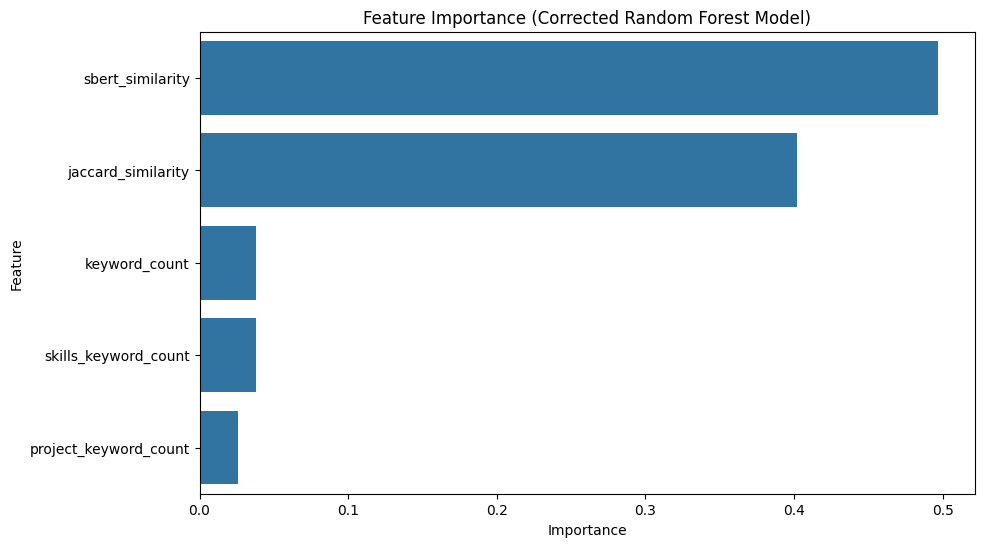

In [8]:
# Train the final Random Forest on the full training data
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train[feature_columns], y_train)

importance_df = pd.DataFrame({ 
        'Feature': feature_columns, 
        'Importance': rf_model.feature_importances_ 
    }).sort_values('Importance', ascending=False)

print('--- Feature Importance from Corrected Model ---')
print(importance_df)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance (Corrected Random Forest Model)')
plt.show()

## Conclusion

This notebook demonstrates the correct way to perform a machine learning analysis on this dataset. By splitting the data *before* creating the target variable and other features, we have prevented data leakage and obtained realistic performance metrics.

**Key Takeaways:**
- The model performance, while not perfect, is now a true reflection of its ability to learn the patterns in our data.
- The feature importance analysis is now valid and gives us credible insights into which factors are most predictive of a high rank in our system.
- This corrected workflow is a robust template for similar prediction tasks, emphasizing the critical importance of maintaining a truly independent test set.